## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [2]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

In [3]:
# ============================================================
# Configuración de MLflow
# ============================================================

import mlflow
import mlflow.sklearn
from datetime import datetime

mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment(
    "13MBID-Experimentacion original (MVP modificado con Undersampling)"
)

c:\MBID\013MBID_AP1_ESTELA-GARCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/07 12:25:00 INFO mlflow.tracking.fluent: Experiment with name '13MBID-Experimentacion original (MVP modificado con Undersampling)' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/MBID/013MBID_AP1_ESTELA-GARCIA/notebooks/mlruns/468881555291659412', creation_time=1778149500152, experiment_id='468881555291659412', last_update_time=1778149500152, lifecycle_stage='active', name='13MBID-Experimentacion original (MVP modificado con Undersampling)', tags={}, trace_location=None, workspace='default'>

In [4]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("TEST_MLFLOW_FUNCIONA")

with mlflow.start_run():
    mlflow.log_metric("prueba", 1.0)

print("RUN DE PRUEBA CREADO")

RUN DE PRUEBA CREADO


In [5]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,edad,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,estado_credito,falta_pago,antiguedad_cliente,estado_civil,...,genero,limite_credito_tc,nivel_educativo,nivel_tarjeta,personas_a_cargo,capacidad_pago,estabilidad_laboral,operaciones_mensuales,gasto_medio_mensual,gasto_promedio_operacion
0,22,ALQUILER,59000,PERSONAL,0.59,16.02,1,Y,36.0,CASADO,...,M,4010.0,UNIVERSITARIO_COMPLETO,Blue,2.0,0.593220,5.590909,2.000000,90.666667,45.333333
1,21,PROPIA,9600,EDUCACIÓN,0.10,11.14,0,N,39.0,CASADO,...,M,12691.0,SECUNDARIO_COMPLETO,Blue,3.0,0.104167,0.238095,3.500000,95.333333,27.238095
2,25,HIPOTECA,9600,SALUD,0.57,12.87,1,N,44.0,SOLTERO,...,F,8256.0,UNIVERSITARIO_COMPLETO,Blue,5.0,0.572917,0.040000,2.750000,107.583333,39.121212
3,23,ALQUILER,65500,SALUD,0.53,15.23,1,N,36.0,CASADO,...,M,3418.0,UNIVERSITARIO_COMPLETO,Blue,3.0,0.534351,0.173913,1.666667,157.250000,94.350000
4,24,ALQUILER,54400,SALUD,0.55,14.27,1,Y,54.0,CASADO,...,M,9095.0,DESCONOCIDO,Blue,1.0,0.643382,0.333333,2.166667,109.500000,50.538462


In [6]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

edad
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
estado_credito
falta_pago
antiguedad_cliente
estado_civil
estado_cliente
genero
limite_credito_tc
nivel_educativo
nivel_tarjeta
personas_a_cargo
capacidad_pago
estabilidad_laboral
operaciones_mensuales
gasto_medio_mensual
gasto_promedio_operacion

Cantidad de filas: 10123


In [7]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (10123, 20)
Dimensiones y: (10123,)


In [8]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7105, 20)
Validation: (2005, 20)
Test: (1013, 20)


In [9]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['edad', 'ingresos', 'pct_ingreso', 'tasa_interes', 'estado_credito', 'antiguedad_cliente', 'limite_credito_tc', 'personas_a_cargo', 'capacidad_pago', 'estabilidad_laboral', 'operaciones_mensuales', 'gasto_medio_mensual', 'gasto_promedio_operacion']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_civil', 'estado_cliente', 'genero', 'nivel_educativo', 'nivel_tarjeta']


In [10]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

falta_pago
N    5864
Y    1241
Name: count, dtype: int64

In [12]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [13]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8254364089775561


In [14]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

In [ ]:
# VERSIÓN INICIAL Se evaluan los modelos con validación cruzada comparando sus resultados



,modelo,accuracy_media,std
1,LinearSVC,0.894300,0.006253
0,LogisticRegression,0.890781,0.003627
2,KNN,0.877410,0.003516
3,DecisionTree,0.871499,0.008080


In [15]:
# ============================================================
# COMPARACIÓN DE MODELOS + MLFLOW (VERSIÓN FINAL)
# ============================================================

# ---------- Instalación ----------
%pip install -q imbalanced-learn mlflow

# ---------- Imports ----------
import os
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from mlflow.models import infer_signature

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler


# ============================================================
# 1. CONFIGURACIÓN MLFLOW (ABSOLUTA Y EXPLÍCITA)
# ============================================================

TRACKING_DIR = os.path.abspath("./mlruns")
mlflow.set_tracking_uri(f"file:{TRACKING_DIR}")
mlflow.set_experiment("13MBID_Comparacion_Modelos_MVP")


# ============================================================
# 2. MÉTRICAS ROBUSTAS
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "roc_auc": "roc_auc"
}


# ============================================================
# 3. EVALUACIÓN + REGISTRO DE TODOS LOS MODELOS
# ============================================================

resultados = []

for nombre, modelo in modelos.items():

    pipeline = ImbPipeline([
        ("prep", preprocessor),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model", modelo)
    ])

    # ---- Cross-validation ----
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )

    fila = {
        "modelo": nombre,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall": scores["test_recall_macro"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }
    resultados.append(fila)

    # ---- MLflow run ----
    with mlflow.start_run(run_name=f"Modelo_{nombre}"):

        pipeline.fit(X_train, y_train)

        signature = infer_signature(
            X_train,
            pipeline.predict(X_train)
        )

        # Parámetros del modelo
        mlflow.log_params(modelo.get_params())

        # Parámetros del experimento
        mlflow.log_params({
            "modelo": nombre,
            "balanceo": "RandomUnderSampler",
            "cv_folds": 5,
            "train_samples": len(X_train)
        })

        # Métricas
        for k, v in fila.items():
            if k != "modelo":
                mlflow.log_metric(k, v)

        # Modelo + firma
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            signature=signature
        )


# ============================================================
# 4. TABLA FINAL EN EL NOTEBOOK
# ============================================================

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("roc_auc", ascending=False)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


2026/05/07 12:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 12:26:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 12:26:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 12:26:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.845461,0.750177,0.846658,0.778872,0.923479
1,LinearSVC,0.847431,0.751559,0.844995,0.780144,0.922835
2,KNN,0.807741,0.714758,0.817154,0.737634,0.886149
3,DecisionTree,0.826742,0.729549,0.823249,0.755221,0.823249


In [ ]:
# Se entrena el mejor modelo

# VERSIÓN INICIAL

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [16]:
# Se entrena el mejor modelo

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

modelo_final = ImbPipeline([
    ("prep", preprocessor),
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(max_iter=5000))
])

modelo_final.fit(X_train, y_train)

,steps,"[('prep', ...), ('undersample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The g

In [17]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           N       0.96      0.85      0.90      1655
           Y       0.54      0.82      0.65       350

    accuracy                           0.85      2005
   macro avg       0.75      0.84      0.78      2005
weighted avg       0.88      0.85      0.86      2005



In [18]:
# Se evalúan los resultados en el conjunto de validación

from sklearn.metrics import classification_report

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           N       0.96      0.85      0.90      1655
           Y       0.54      0.82      0.65       350

    accuracy                           0.85      2005
   macro avg       0.75      0.84      0.78      2005
weighted avg       0.88      0.85      0.86      2005



In [19]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           N       0.96      0.86      0.91       836
           Y       0.56      0.85      0.67       177

    accuracy                           0.86      1013
   macro avg       0.76      0.85      0.79      1013
weighted avg       0.89      0.86      0.87      1013



In [22]:
#  VERSION INICIAL Se genera una matriz de confusión para el conjunto de test

#cm = confusion_matrix(y_test, y_test_pred)

#disp = ConfusionMatrixDisplay(confusion_matrix=cm)

#disp.plot(cmap="Blues")

#plt.title("Matriz de Confusión")
#plt.show()

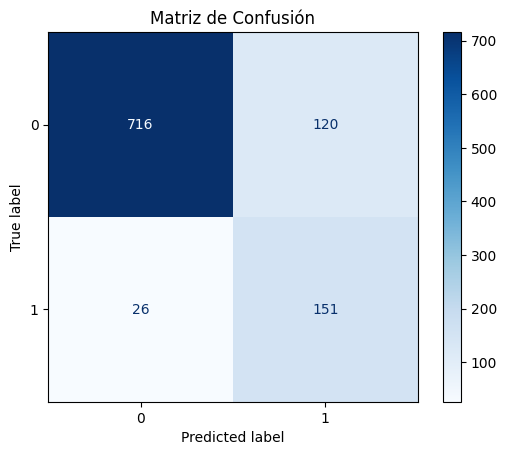

In [29]:
# Se genera una matriz de confusión para el conjunto de test

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones en test
y_test_pred = modelo_final.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()